# Karak tutorial 1: from PNG export to element cube

Karak turns a folder of SEM-EDS element maps into a mineral phase map. The instrument software (TIMA, in the datasets karak was built for) exports each element as a false-color PNG: pixel color encodes X-ray count intensity through a colormap, usually jet. The scalar values themselves are not in the file. The first job of the pipeline is to get them back.

This notebook walks through the `load_elements` stage, the first node in every built-in flow:

1. Discover the element map files and parse element names from filenames.
2. Invert the colormap: RGB back to scalar intensity in [0, 1].
3. Downsample and trim the maps.
4. Stack everything into an (H, W, C) element cube plus a BSE image.

It stops there. Masking, denoising, and clustering get their own notebooks.

In [1]:
import logging
from pathlib import Path

import imageio.v2 as imageio
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from karak.config import DownsampleConfig
from karak.io.loaders import (
    build_compositional_cube,
    invert_colormap,
    load_element_maps,
)

# The loader logs one line per file it loads; show those lines here.
logging.basicConfig(level=logging.INFO, format="%(message)s")

plt.rcParams["figure.dpi"] = 100

## A synthetic dataset

Real TIMA exports are hundreds of megabytes, so this notebook builds a small synthetic scene instead. It has the same anatomy as a real export:

- a round grain rich in Mg and Fe,
- a diagonal Ca vein,
- a Si-rich matrix,
- an epoxy strip on the left with no signal (pure black pixels),
- a light-gray header band across the top, standing in for the scale-bar strip TIMA prints on every image.

Each element gets rendered through the jet colormap exactly as the instrument would render it. We keep the ground-truth intensity arrays in memory so we can measure the inversion error later. If you have a real export, point `DATA_DIR` at it and skip this cell.

In [2]:
DATA_DIR = Path("data/tutorial_synthetic")
HEADER_PX = 24  # height of the fake header band, in pixels
H = W = 256
rng = np.random.default_rng(42)

yy, xx = np.mgrid[0:H, 0:W]
grain = (yy - 150) ** 2 + (xx - 110) ** 2 < 55**2
vein = np.abs(xx - (0.5 * yy + 130)) < 5
epoxy = xx < 24

truth = {
    "Fe": 0.15 + 0.55 * grain,
    "Mg": 0.10 + 0.70 * grain,
    "Si": 0.55 - 0.35 * grain,
    "Ca": 0.12 + 0.65 * vein,
}

DATA_DIR.mkdir(parents=True, exist_ok=True)
jet = matplotlib.colormaps["jet"]
for element, values in truth.items():
    values = np.clip(values + rng.normal(0, 0.02, values.shape), 0.01, 0.99)
    values[epoxy] = 0.0
    truth[element] = values.astype(np.float32)

    rgb = (jet(values)[..., :3] * 255).astype(np.uint8)
    rgb[epoxy] = 0  # no-data pixels are pure black in TIMA exports
    rgb[:HEADER_PX] = 230  # header band
    rgb[4:12, 8:88] = 0  # fake scale bar inside the header
    imageio.imwrite(DATA_DIR / f"tut-01-{element}.png", rgb)

# BSE/SEM channel: true grayscale, brightness tracks mean atomic density
sem = (255 * (0.30 + 0.40 * grain + 0.20 * vein)).astype(np.uint8)
sem[epoxy] = 0
sem = np.repeat(sem[..., None], 3, axis=-1)
sem[:HEADER_PX] = 230
imageio.imwrite(DATA_DIR / "tut-01-SEM.png", sem)

sorted(p.name for p in DATA_DIR.glob("*.png"))

['tut-01-Ca.png',
 'tut-01-Fe.png',
 'tut-01-Mg.png',
 'tut-01-SEM.png',
 'tut-01-Si.png']

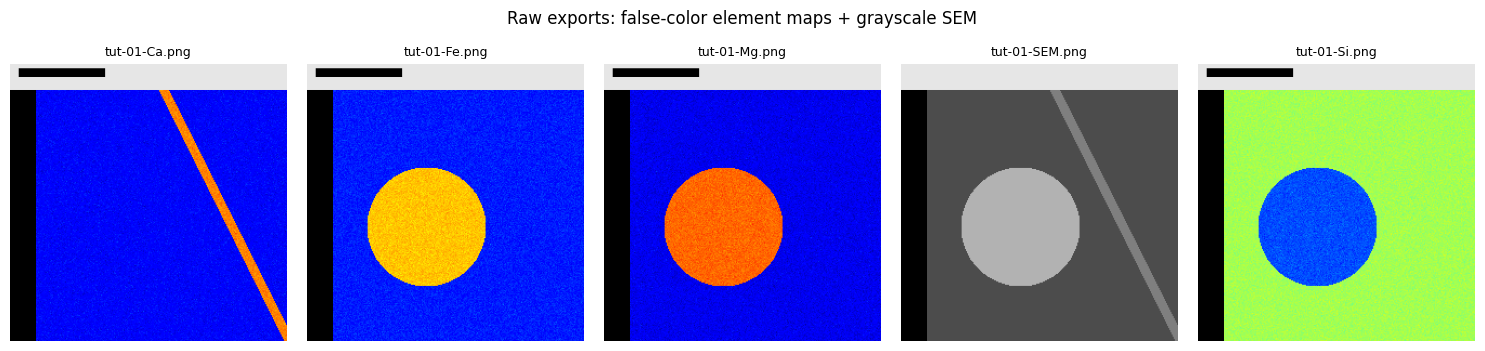

In [3]:
files = sorted(DATA_DIR.glob("*.png"))
fig, axes = plt.subplots(1, len(files), figsize=(3 * len(files), 3.4))
for ax, path in zip(axes, files):
    ax.imshow(imageio.imread(path))
    ax.set_title(path.name, fontsize=9)
    ax.axis("off")
fig.suptitle("Raw exports: false-color element maps + grayscale SEM", y=1.02)
plt.tight_layout()

This is what the pipeline receives. Blue is low intensity and red is high, per the jet colormap. The left strip is pure black, the no-data marker. The band across the top is the instrument header; it is not sample data and has to be trimmed off. The SEM image is true grayscale, so it needs no colormap inversion.

## Step 1: file discovery

The loader globs `*.png` in the input directory and parses the element name out of each filename. With no explicit `filename_pattern` it applies the legacy TIMA convention: split the stem on `-` and join everything from the third part on. Joining, rather than taking one part, keeps hyphenated names such as `Fe-K` intact.

So `tut-01-Fe.png` parses to `Fe`, and `tut-01-SEM.png` parses to `SEM`. The name `SEM` is the configured BSE channel, so the loader stores that file separately as grayscale instead of treating it as an element.

Datasets with other naming schemes set `filename_pattern` (for example `'Map_NWA-5218_eds_{element}.bmp'`) and `file_glob` on the stage; no code changes needed.

In [4]:
for path in files:
    element = "-".join(path.stem.split("-")[2:])  # the loader's legacy rule
    kind = "BSE channel" if element == "SEM" else "element map"
    print(f"{path.name:20s} -> {element:4s} ({kind})")

tut-01-Ca.png        -> Ca   (element map)
tut-01-Fe.png        -> Fe   (element map)
tut-01-Mg.png        -> Mg   (element map)
tut-01-SEM.png       -> SEM  (BSE channel)
tut-01-Si.png        -> Si   (element map)


## Step 2: colormap inversion

The export mapped a scalar in [0, 1] to an RGB color. Karak inverts that with a lookup table:

1. Sample the jet colormap at 4096 points to get a palette of known (color, scalar) pairs.
2. Build a 256×256×256 table that maps every possible RGB triplet to the scalar of the nearest palette color (nearest-neighbor search with a KD-tree).
3. Inverting an image is then a single array indexing operation.

Nearest-neighbor matters because uint8 rounding and image resampling push pixel colors slightly off the exact palette; snapping to the closest palette entry absorbs that. Pure black maps to 0.0 regardless of palette, which is how the epoxy strip stays at zero.

Building the table takes about a minute the first time. Karak caches it in `.cache/` at the repo root, keyed by a fingerprint of the palette, so each colormap pays that cost once ever. Other colormaps work too: `colormap_spec` accepts any matplotlib name (`'cmap:viridis'`) or a custom palette file (`'lut:my_palette.npy'`).

In [5]:
element = "Fe"
raw_rgb = imageio.imread(DATA_DIR / f"tut-01-{element}.png")
recovered = invert_colormap(raw_rgb, colormap_spec="cmap:jet")
print(
    f"{recovered.shape} {recovered.dtype}, "
    f"range [{recovered.min():.3f}, {recovered.max():.3f}]"
)

Loading cached LUT from /home/brendon/Projects/Science/karak/.cache/colormap_full_lut_9f80fbbcb838.npy


(256, 256) float32, range [0.000, 0.779]


mean abs error over sample area: 0.00199
max  abs error over sample area: 0.01559


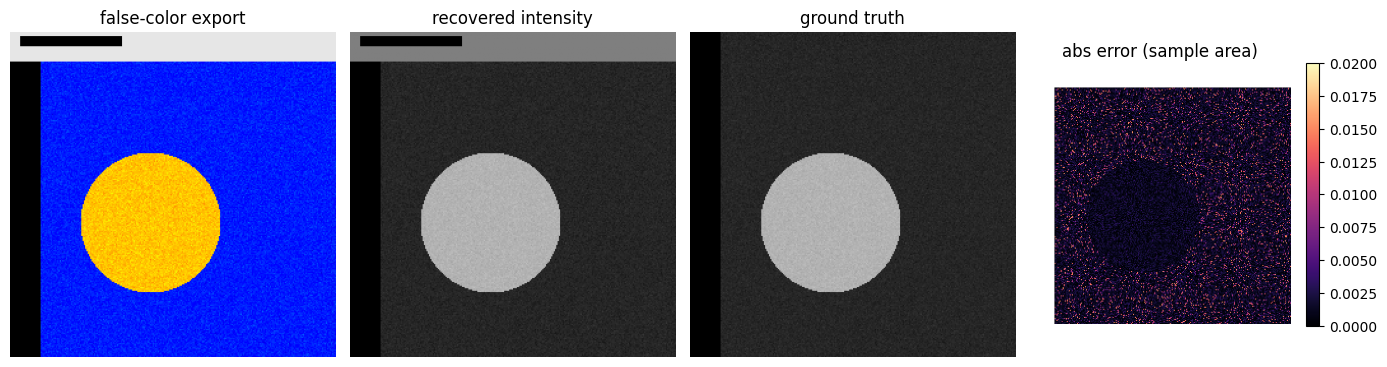

In [6]:
sample = ~epoxy
sample[:HEADER_PX] = False  # ground truth is undefined under the header band
error = np.abs(recovered - truth[element])

fig, axes = plt.subplots(1, 4, figsize=(14, 3.6))
axes[0].imshow(raw_rgb)
axes[0].set_title("false-color export")
axes[1].imshow(recovered, cmap="gray", vmin=0, vmax=1)
axes[1].set_title("recovered intensity")
axes[2].imshow(truth[element], cmap="gray", vmin=0, vmax=1)
axes[2].set_title("ground truth")
im = axes[3].imshow(np.where(sample, error, np.nan), cmap="magma", vmin=0, vmax=0.02)
axes[3].set_title("abs error (sample area)")
fig.colorbar(im, ax=axes[3], shrink=0.8)
for ax in axes:
    ax.axis("off")
plt.tight_layout()

print(f"mean abs error over sample area: {error[sample].mean():.5f}")
print(f"max  abs error over sample area: {error[sample].max():.5f}")

Two things to check in this figure:

- Over the sample area, the recovered image matches the ground truth to within uint8 quantization, roughly 0.002 mean error. The inversion is close to lossless for on-palette colors.
- The header band recovers garbage. Gray is not a jet color, so the nearest-neighbor lookup snaps those pixels to whatever jet color happens to be closest. Same for the black scale bar, which lands at 0. This is exactly why the loader trims the header before any analysis.

## Step 3: downsample and trim

`load_element_maps` wraps discovery and inversion, then cleans up the geometry:

- `downscale_local_mean` averages each factor×factor block (default factor 2). That cuts memory 4× and averages out per-pixel counting noise.
- Edge trims remove the header band and any scan artifacts on the borders. Trim values are given in original-image pixels; the loader divides them by the downsample factor because trimming happens after downsampling.

Our header band is 24 px, so `header_trim_px=24`. With factor 2 each 256×256 image becomes 128×128, then loses the top 12 rows: final shape 116×128.

In [7]:
downsample = DownsampleConfig(header_trim_px=HEADER_PX, downsample_factor=2)
elements, bse, names = load_element_maps(
    str(DATA_DIR),
    downsample,
    exclude_elements=[],
    bse_channel="SEM",
)
print()
print("elements loaded:", names)
print("shape per element:", elements[names[0]].shape, "| BSE:", bse.shape)

Loaded element 'Ca' (inverted via cmap:jet): shape (116, 128), range [0.0000, 0.8057]


Loaded element 'Fe' (inverted via cmap:jet): shape (116, 128), range [0.0000, 0.7341]


Loaded element 'Mg' (inverted via cmap:jet): shape (116, 128), range [0.0000, 0.8354]


Loaded BSE channel 'SEM': shape (116, 128)


Loaded element 'Si' (inverted via cmap:jet): shape (116, 128), range [0.0000, 0.5863]


Loaded 4 element channels + BSE (SEM).  Shape: (116, 128)



elements loaded: ['Ca', 'Fe', 'Mg', 'Si']
shape per element: (116, 128) | BSE: (116, 128)


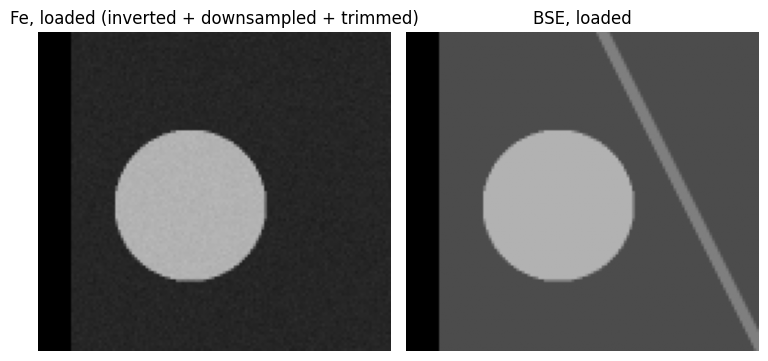

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(7.5, 3.6))
axes[0].imshow(elements["Fe"], cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Fe, loaded (inverted + downsampled + trimmed)")
axes[1].imshow(bse, cmap="gray", vmin=0, vmax=1)
axes[1].set_title("BSE, loaded")
for ax in axes:
    ax.axis("off")
plt.tight_layout()

The header band is gone from both channels, and the epoxy strip is still zero. These arrays are what every later stage sees; the original PNGs are never read again.

## Step 4: the element cube

`build_compositional_cube` stacks the per-element arrays into one (H, W, C) float32 cube, with channels in sorted element-name order. This cube is the central data structure of the pipeline: from here on, each pixel is a C-dimensional composition vector, and clustering groups pixels whose vectors look alike.

cube: (116, 128, 4) float32 | channel order: ['Ca', 'Fe', 'Mg', 'Si']


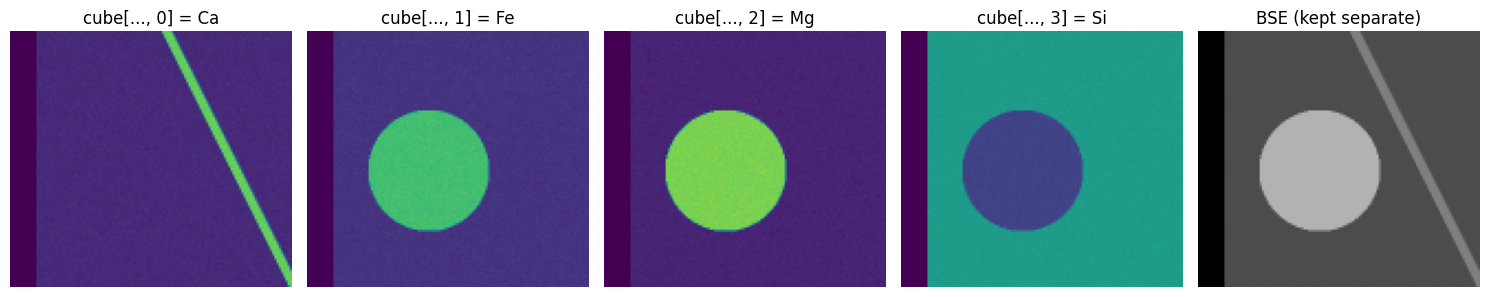

In [9]:
cube = build_compositional_cube(elements, names)
print("cube:", cube.shape, cube.dtype, "| channel order:", names)

fig, axes = plt.subplots(1, len(names) + 1, figsize=(3 * (len(names) + 1), 3.2))
for i, (ax, name) in enumerate(zip(axes, names)):
    ax.imshow(cube[..., i], cmap="viridis", vmin=0, vmax=1)
    ax.set_title(f"cube[..., {i}] = {name}")
    ax.axis("off")
axes[-1].imshow(bse, cmap="gray", vmin=0, vmax=1)
axes[-1].set_title("BSE (kept separate)")
axes[-1].axis("off")
plt.tight_layout()

The grain reads high in Fe and Mg and low in Si, the vein reads high in Ca, and the matrix carries the Si. The BSE image stays outside the cube: it is not an element channel, but later stages use it for masking and QC figures.

## The same thing as a flow stage

In the pipeline you do not call these functions yourself. The `load_elements` stage wraps them, declares every knob above as a typed `Param` (input directory, glob, filename pattern, colormap, trims, downsample factor), and returns typed payloads instead of bare arrays. It is the `src` node of every built-in flow, which is why `karak run --builtin global --input DIR --out BASE` starts here.

Running the stage directly shows the payloads it produces. Note the `header_trim_px` override: the stage default is 100 px, the real TIMA header height, but our synthetic header is 24 px. On the command line the same override is `--set src.header_trim_px=24`.

In [10]:
from karak.stages.load import LoadElementsStage

outputs = LoadElementsStage().run(
    {},
    {"input_dir": str(DATA_DIR), "header_trim_px": HEADER_PX},
)
cube_payload = outputs["cube"]
bse_payload = outputs["bse"]

print(
    type(cube_payload).__name__,
    cube_payload.pixels.shape,
    cube_payload.element_names,
    cube_payload.space,
)
print(type(bse_payload).__name__, bse_payload.pixels.shape)

np.testing.assert_array_equal(cube_payload.pixels, cube)
print("stage output matches the cube we built by hand")

Loaded element 'Ca' (inverted via cmap:jet): shape (116, 128), range [0.0000, 0.8057]


Loaded element 'Fe' (inverted via cmap:jet): shape (116, 128), range [0.0000, 0.7341]


Loaded element 'Mg' (inverted via cmap:jet): shape (116, 128), range [0.0000, 0.8354]


Loaded BSE channel 'SEM': shape (116, 128)


Loaded element 'Si' (inverted via cmap:jet): shape (116, 128), range [0.0000, 0.5863]


Loaded 4 element channels + BSE (SEM).  Shape: (116, 128)


ElementCube (116, 128, 4) ('Ca', 'Fe', 'Mg', 'Si') Space.RAW
BseImage (116, 128)
stage output matches the cube we built by hand


The stage returns an `ElementCube` tagged `space=RAW` and a `BseImage`. The space tag is how the flow validator catches wiring mistakes: a stage that expects normalized data refuses a raw cube at validation time, before anything runs.

That is the whole first stage. The cube values are relative intensities in [0, 1], not concentrations, and the epoxy pixels are still in the arrays. Deciding which pixels are actually sample is the job of the next node in the flow, `mask`, which is where tutorial 2 picks up.